In [238]:
import importlib, sys
# Force reload the module
importlib.reload(sys.modules['Class_definitions'])
importlib.reload(sys.modules['simulate_population'])

<module 'simulate_population' from 'C:\\Users\\dinab\\Desktop\\PhD Projects\\Ensemble methods\\GitHub_App\\medicaljourneys\\simulate_population.py'>

In [239]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from simulate_population import sim_population

In [240]:
from Class_definitions import (    prepare_data_simple_timeseries,    train_simple_timeseries,
    get_cindex_simple_timeseries,    SimpleBinaryTimeSeries,
    simplecox, get_cindex_for_event)

In [241]:
#============================================================================
# HYPERPARAMETERS (matching Simple_Cox_with_NN-Copy1)
# ============================================================================
N_POPULATION = 5000

BATCH_SIZE = 512
EPOCHS = 300
HIDDEN_LAYERS_COX = (64, 32)
HIDDEN_LAYERS_MULTIBINARY = (64, 32)
STEP_FORWARD = 2
N_STEPS = 5
N_INTERVALS = int(N_STEPS * STEP_FORWARD)  # time split every 2 years
COVARIATE_COLS = ["age_start", "bmi", "hyp", "smoke", "sex", "eth1", "eth2"]
EVENT_TYPES = ["a", "b", "c", "d", "e"]

# ============================================================================
# PART A: Generate Data
# ============================================================================
print("=" * 80)
print("PART A: Generating Simulation Data")
print("=" * 80)
np.random.seed(42); torch.manual_seed(42) # Set random seed for reproducibility

# Generate population with 5 steps forward, step_forward=2
population_train = sim_population(N= int(N_POPULATION*0.8), step_forward=STEP_FORWARD, randomseed=42)
population_test = sim_population(N= int(N_POPULATION*0.2), step_forward=STEP_FORWARD, randomseed=42+1)
for i in range(N_STEPS): 
    population_train.step()
    population_test.step()

# Get Cox format data (train/test split)
df_cox_train = population_train.to_cox_format()
df_cox_test = population_test.to_cox_format()
print(f"Cox format data shape (train, test): {df_cox_train.shape}, {df_cox_test.shape}")
print(f"Columns: {df_cox.columns.tolist()}\n")

print("=" * 80)
print(f"Prepare the data for the time series; {len(df_cox)} x {N_STEPS+1} samples")
print("=" * 80)

df_train = prepare_data_simple_timeseries( population_train)
df_test = prepare_data_simple_timeseries(population_test)

print(f"Train set: {len(df_train)} rows")
print(f"Test set: {len(df_test)} rows")


PART A: Generating Simulation Data
Cox format data shape (train, test): (4000, 18), (1000, 18)
Columns: ['id', 'age_start', 'bmi', 'hyp', 'smoke', 'sex', 'eth1', 'eth2', 'event_a', 'time_a', 'event_b', 'time_b', 'event_c', 'time_c', 'event_d', 'time_d', 'event_e', 'time_e']

Prepare the data for the time series; 10000 x 6 samples
Train set: 24000 rows
Test set: 6000 rows


# Fit and validate the binary models 

In [242]:
cindex_df_list = list() 

# ===== SIMPLE COX MODEL  =====
print("\n[1/4] Training CoxPH...")
cox_models = {}
cindex_cox = {}
for e in EVENT_TYPES:
    cox_model = simplecox(df_cox_train, covariate_cols=COVARIATE_COLS, event_type=e)
    cox_models[e] = cox_model
    # Get c-index on TEST set (same as neural networks)
    predictions = 1-cox_model.predict_partial_hazard(df_cox_test[COVARIATE_COLS])
    cindex_cox[e] = get_cindex_for_event(predictions, df_cox_test, e)
for e in EVENT_TYPES:
    cindex_df_list.append({'Model': 'CoxPH','Event': e, 'C-Index': cindex_cox[e]})

print(pd.DataFrame(cindex_df_list).pivot_table(index='Event', columns='Model', values='C-Index'))

# ===== LINEAR MODEL (NO HIDDEN LAYERS) =====
print("\n[2/4] Training Simple Binary TimeSeries (Linear)...")
model_linear = train_simple_timeseries(
    df_train,     features=COVARIATE_COLS,    event_types=EVENT_TYPES,    hidden_dims=(),  # NO hidden layers
    lr=0.01,    epochs=300,    batch_size=512)
cindex_linear = get_cindex_simple_timeseries(    model_linear, df_test, COVARIATE_COLS, EVENT_TYPES)
for e in EVENT_TYPES:
    cindex_df_list.append({'Model': 'Binary TimeSeries (Linear)','Event': e, 'C-Index': cindex_linear[e] })
print(pd.DataFrame(cindex_df_list).pivot_table(index='Event', columns='Model', values='C-Index'))

# ===== WITH HIDDEN LAYERS =====
print("\n[3/4] Training Simple Binary TimeSeries (64-32)...")
model_hidden = train_simple_timeseries(
    df_train,    features=COVARIATE_COLS,    event_types=EVENT_TYPES,    hidden_dims=(16, 16),  # Two hidden layers
    lr=0.01, epochs=300,   batch_size=512)
cindex_hidden = get_cindex_simple_timeseries(    model_hidden, df_test, COVARIATE_COLS, EVENT_TYPES)
for e in EVENT_TYPES:
    cindex_df_list.append({'Model': 'Binary TimeSeries (64-32)','Event': e,'C-Index': cindex_hidden[e] })
print(pd.DataFrame(cindex_df_list).pivot_table(index='Event', columns='Model', values='C-Index'))

# # ===== WITH MORE LAYERS =====
# print("\n[4/4] Training Simple Binary TimeSeries (128-64-32)...")
# model_deep = train_simple_timeseries(
#     df_train,     features=COVARIATE_COLS,    event_types=EVENT_TYPES,    hidden_dims=(128, 64, 32),  # Three hidden layers
#     lr=0.01,    epochs=300,    batch_size=512)
# cindex_deep = get_cindex_simple_timeseries(    model_deep, df_test, COVARIATE_COLS, EVENT_TYPES)
# for e in EVENT_TYPES:
#     cindex_df_list.append({'Model': 'Binary TimeSeries (128-64-32)','Event': e,'C-Index': cindex_deep[e]})
# print(pd.DataFrame(cindex_df_list).pivot_table(index='Event', columns='Model', values='C-Index'))

# ===== RESULTS TABLE =====
cindex_df = pd.DataFrame(cindex_df_list)
cindex_pivot = cindex_df.pivot_table(index='Event', columns='Model', values='C-Index')
print("\n" + cindex_pivot.to_string())


[1/4] Training CoxPH...
Model     CoxPH
Event          
a      0.720463
b      0.665894
c      0.634706
d      0.618316
e      0.606212

[2/4] Training Simple Binary TimeSeries (Linear)...
Epoch 1/300, Loss: 1.3156
Epoch 51/300, Loss: 0.3904
Epoch 101/300, Loss: 0.3905
Epoch 151/300, Loss: 0.3901
Epoch 201/300, Loss: 0.3909
Epoch 251/300, Loss: 0.3898
Epoch 300/300, Loss: 0.3901
Model  Binary TimeSeries (Linear)     CoxPH
Event                                      
a                        0.700288  0.720463
b                        0.649660  0.665894
c                        0.632489  0.634706
d                        0.604876  0.618316
e                        0.577880  0.606212

[3/4] Training Simple Binary TimeSeries (64-32)...
Epoch 1/300, Loss: 0.4962
Epoch 51/300, Loss: 0.3655
Epoch 101/300, Loss: 0.3638
Epoch 151/300, Loss: 0.3631
Epoch 201/300, Loss: 0.3619
Epoch 251/300, Loss: 0.3620
Epoch 300/300, Loss: 0.3622
Model  Binary TimeSeries (64-32)  Binary TimeSeries (Linear)    

<Axes: title={'center': 'C-Index'}, xlabel='Event'>

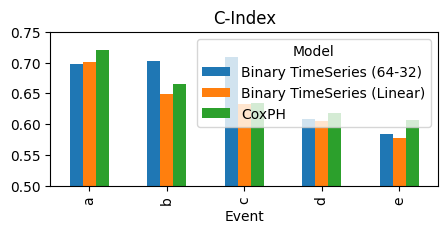

In [243]:
cindex_pivot.plot.bar(figsize = (5,2),title ="C-Index", ylim = (0.5,0.75))

In [244]:
coefdf = round(cox_models["a"].summary[['coef']],4)
coefdf2 = pd.DataFrame(model_linear.get_beta(), columns = coefdf.index, index = event_types ).T
coefdf2["coxa"] =  round(cox_models["a"].summary[['coef']],4)
coefdf2["coxb"] =  round(cox_models["b"].summary[['coef']],4)
coefdf2["coxc"] =  round(cox_models["c"].summary[['coef']],4)
coefdf2["coxd"] =  round(cox_models["d"].summary[['coef']],4)
coefdf2["coxe"] =  round(cox_models["e"].summary[['coef']],4)
print("Binary vs Cox betas")
coefdf2.loc[:, ["coxa", "a", "coxb", "b", "coxc", "c","coxd","d", "coxe", "e"]]


Binary vs Cox betas


,coxa,a,coxb,b,coxc,c,coxd,d,coxe,e
covariate,,,,,,,,,,
age_start,0.0280,0.035735,0.0330,0.048991,0.0147,0.018449,0.0257,0.020723,0.0228,0.014873
bmi,0.5010,0.676379,0.0707,0.128149,0.0258,0.069659,0.0542,0.047266,-0.0058,0.003650
hyp,0.7328,1.023976,0.6482,0.969530,0.1615,0.206629,0.0087,0.021499,-0.0548,-0.086636
smoke,-0.0424,-0.017693,0.0015,-0.059040,0.9367,1.274786,0.0357,0.004665,-0.0052,-0.034596
sex,-0.0417,-0.041680,-0.0350,-0.023066,-0.0533,0.003039,0.0960,0.087441,0.0112,0.089490
eth1,0.5649,0.692855,0.1191,0.188968,0.0170,0.046772,0.1444,0.153770,0.1655,0.198324
eth2,1.9260,2.842469,0.3075,0.448699,0.0816,0.063015,0.4254,0.507424,0.5785,0.547696


<Axes: title={'center': 'Betas:Binary vs Cox'}>

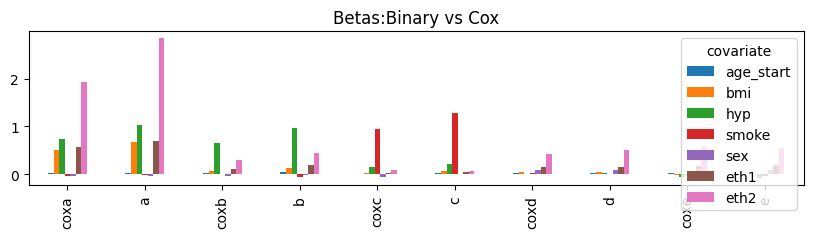

In [245]:
coefdf2.loc[:, 
    ["coxa", "a", "coxb", "b", "coxc", "c","coxd","d", "coxe", "e"]].T.plot.bar(
        figsize = (10,2), title = "Betas:Binary vs Cox")

In [246]:
event_types = ["a","b", "c", "d","e"]
model_hidden.get_cumulative_probability(df_train_long.iloc[1][COVARIATE_COLS], event_types=event_types)

,a,b,c,d,e
Interval,,,,,
0,0.238337,0.110268,0.181908,0.013248,0.009753
1,0.452201,0.268397,0.333813,0.024331,0.019853
2,0.623766,0.443602,0.465774,0.039706,0.031223
3,0.752802,0.602344,0.574918,0.057293,0.041841
4,0.841060,0.738310,0.666614,0.072703,0.057033
5,0.897380,0.830614,0.737986,0.092512,0.072352


In [248]:
model_hidden.get_survival_probability(df_train_long.iloc[1][COVARIATE_COLS], event_types=event_types)

,a,b,c,d,e
Interval,,,,,
0,0.761663,0.889732,0.818092,0.986752,0.990247
1,0.547799,0.731603,0.666187,0.975669,0.980147
2,0.376234,0.556398,0.534226,0.960294,0.968777
3,0.247198,0.397656,0.425082,0.942707,0.958159
4,0.158940,0.261690,0.333386,0.927297,0.942967
5,0.102620,0.169386,0.262014,0.907488,0.927648
